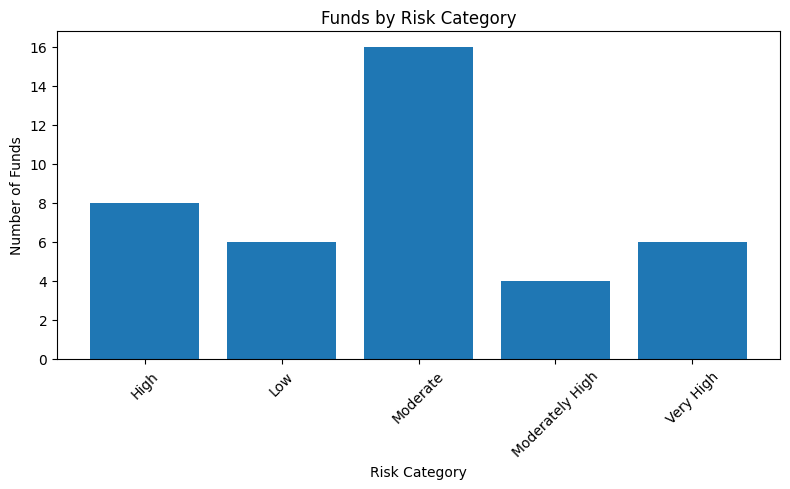

In [19]:
fund_master = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "fund_master_clean.csv"
)

risk_summary = (
    fund_master
    .groupby("risk_category")
    .agg(
        number_of_funds=("amfi_code", "count")
    )
    .reset_index()
)

risk_summary

risk_summary.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "risk_category_summary.csv",
    index=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    risk_summary["risk_category"],
    risk_summary["number_of_funds"]
)

plt.title("Funds by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    BASE_DIR /
    "Reports" /
    "risk_category_chart.png"
)

plt.show()

DAY 6 - Deliverable 6

## Risk Category Analysis

Sector concentration analysis could not be performed because portfolio holdings data was unavailable.

Instead, funds were classified and analysed using the available risk_category field from the fund master dataset.

This provides a high-level view of the distribution of mutual funds across different risk profiles.

In [20]:
txn = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "investor_transactions_clean.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

txn = txn.sort_values(
    ["investor_id", "transaction_date"]
)

txn["gap_days"] = (
    txn.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

continuity = (
    txn.groupby("investor_id")
       .agg(
           total_transactions=("transaction_date","count"),
           avg_gap_days=("gap_days","mean"),
           max_gap_days=("gap_days","max")
       )
       .reset_index()
)

continuity = continuity[
    continuity["total_transactions"] >= 6
]

continuity["at_risk"] = (
    continuity["max_gap_days"] > 35
)

continuity.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "sip_continuity.csv",
    index=False
)

print("Saved")

Saved


04 - SIP continuation analysis: For each
investor with 6+ SIP transactions,
compute average gap between
transactions. Flag investors with gaps > 35 days as 'at-risk

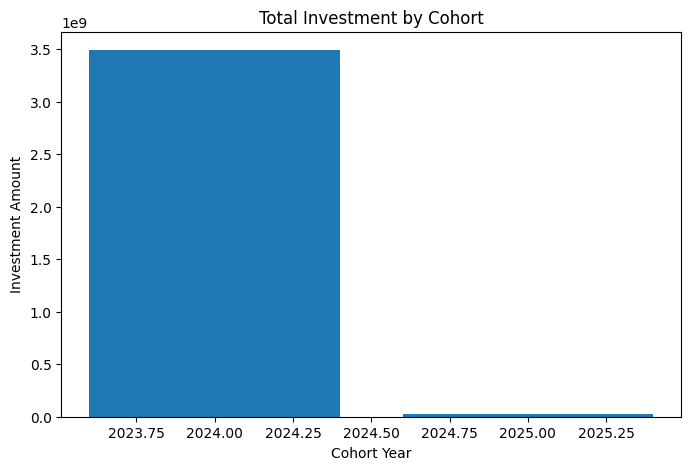

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    cohort_analysis["cohort_year"],
    cohort_analysis["total_invested"]
)

plt.title("Total Investment by Cohort")
plt.xlabel("Cohort Year")
plt.ylabel("Investment Amount")

plt.show()

In [16]:
cohort_analysis.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "cohort_analysis.csv",
    index=False
)

print("Saved")

Saved


In [15]:
cohort_analysis = (
    txn.groupby("cohort_year")
       .agg(
           investors=("investor_id", "nunique"),
           avg_sip_amount=("amount_inr", "mean"),
           total_invested=("amount_inr", "sum")
       )
       .reset_index()
)

cohort_analysis

,cohort_year,investors,avg_sip_amount,total_invested
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


In [14]:
txn = txn.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [13]:
first_txn = (
    txn.groupby("investor_id")["transaction_date"]
       .min()
       .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [12]:
txn = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "investor_transactions_clean.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


03 - Investor cohort analysis: Group
investors by first transaction year
(2024/2025) Compute average SIP
amount, total invested, fund
preference by cohort

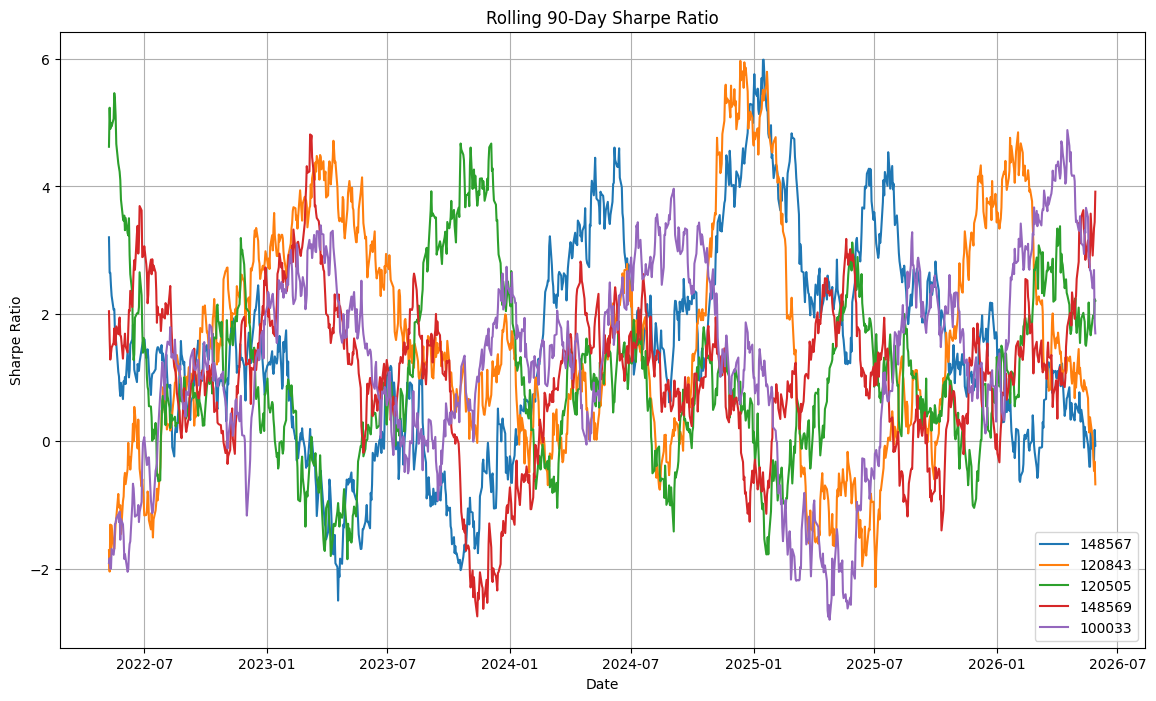

Saved


In [11]:
rf_daily = 0.065 / 252

plt.figure(figsize=(14,8))

for code in top5:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    rolling_mean = (
        fund["daily_return"]
        .rolling(90)
        .mean()
    )

    rolling_std = (
        fund["daily_return"]
        .rolling(90)
        .std()
    )

    rolling_sharpe = (
        (rolling_mean - rf_daily)
        / rolling_std
    ) * np.sqrt(252)

    plt.plot(
        fund["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

reports_dir = (
    BASE_DIR / "Reports"
)

reports_dir.mkdir(
    exist_ok=True
)

plt.savefig(
    reports_dir /
    "rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

print("Saved")

In [9]:
rankings = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "fund_rankings.csv"
)

top5 = (
    rankings
    .sort_values("rank")
    .head(5)["amfi_code"]
    .tolist()
)

print(top5)

[148567, 120843, 120505, 148569, 100033]


In [8]:
nav = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

02 - Compute Rolling 90-day Sharpe Ratio
for 5 funds: rolling_sharpe =
returns.rolling(90).mean() /
returns.rolling(90).std() * sqrt(252)
Plot over time

In [6]:
var_cvar_df.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [5]:
var_cvar_df.to_csv(
    BASE_DIR /
    "Data" /
    "processed" /
    "var_cvar_report.csv",
    index=False
)

print("Saved")

Saved


In [4]:
results = []

for code, group in nav.groupby("amfi_code"):

    returns = group[
        "daily_return"
    ].dropna()

    if len(returns) < 50:
        continue

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    results.append([
        code,
        var_95,
        cvar_95
    ])

var_cvar_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [3]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [2]:
nav = pd.read_csv(
    BASE_DIR / "Data" / "processed" / "nav_history_clean.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd().parent

01 - Compute Historical VaR (95%) for
each fund: VaR = 5th percentile of
daily return distribution CVaR = mean
of returns below VaR threshold